# HR Analytics: Understanding Employee Attrition and Workforce Retention

**Author:** Hoang Do Phan  
**Date:** May 2026  
**Project Type:** Portfolio Data Analytics Project  
**Tools:** Python + Power BI  

---



# 1. Business Understanding

## Background

Employee attrition is a major challenge for organizations across industries. High turnover rates can lead to increased recruitment costs, loss of organizational knowledge, reduced productivity, and lower employee morale.

Understanding why employees leave an organization is essential for developing effective retention strategies. By leveraging HR analytics, organizations can identify patterns in employee behavior, workplace satisfaction, compensation, and career development opportunities that may contribute to turnover.

This project investigates employee attrition using workforce data and applies data analytics techniques to uncover key drivers of employee turnover. The findings are intended to support data-driven decision-making and improve long-term workforce retention.

---

## Business Problem

Employee turnover can negatively impact organizational performance and increase operational costs.

The organization wants to better understand the factors associated with employee attrition and identify opportunities to improve employee retention.

---

## Project Goal

The goal of this project is to analyze employee data and identify the key factors that influence attrition.

The results will be used to develop actionable recommendations that help organizations improve employee satisfaction, strengthen retention strategies, and support workforce planning.

---


## Key Questions

1. What is the overall employee attrition rate?
2. Which departments experience the highest turnover?
3. How does employee satisfaction influence attrition?
4. Does salary level impact employee retention?
5. How do workload and working hours affect employee turnover?
6. Do promotion opportunities contribute to employee retention?

---

## Stakeholders

- Human Resources Department
- HR Managers
- Department Managers
- Executive Leadership Team
- Workforce Planning Team

---


# 2. Data Understanding

## Data Source

This project uses the HR Employee Attrition Dataset, a publicly available dataset commonly used for HR analytics and workforce management projects.

The dataset contains information related to employee satisfaction, performance, workload, compensation, promotion history, and employment status.

---

## Dataset Features

| Variable | Description |
|---|---|
| satisfaction_level | Employee satisfaction score |
| last_evaluation | Most recent performance evaluation |
| number_project | Number of projects assigned |
| average_montly_hours | Average monthly working hours |
| time_spend_company | Number of years employed |
| Work_accident | Work accident indicator |
| promotion_last_5years | Promotion status |
| sales | Department |
| salary | Salary category |
| left | Employee attrition status |

---

## Dataset Limitations

- The dataset represents a single organizational environment.
- Demographic information such as age, gender, and education level is not available.
- External labor market factors are not included.
- Employee exit reasons are not recorded.
- Results may not be generalizable across all industries.

---

## Data Quality Assessment

| Criteria | Evaluation |
|---|---|
| Reliable | Medium |
| Original | Medium |
| Comprehensive | High |
| Current | Medium |
| Cited | Medium |

Overall, the dataset is suitable for exploratory data analysis and educational HR analytics projects.

# 3. Data Preparation

## Overview

After inspecting the dataset, several data preparation steps were performed to improve data quality and make the dataset easier to analyze.

The preparation process included removing duplicate records, validating variable values, and creating additional fields that support analysis and dashboard development.

## 3.1 Import Libraries

The required Python libraries were imported to support data loading, cleaning, transformation, and analysis.

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Display all columns when viewing dataframes
pd.set_option('display.max_columns', None)

# Display wider tables
pd.set_option('display.width', 1000)

## 3.2 Load Dataset

The HR Employee Attrition dataset was uploaded and loaded into a pandas dataframe for inspection and preparation.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [3]:
df = pd.read_csv("HR_comma_sep.csv")

df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## 3.3 Initial Data Inspection

The dataset was reviewed to understand its structure, variables, and overall quality before cleaning.


In [4]:
df.shape

(14999, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## 3.4 Missing Values

Missing values were checked to ensure data completeness.

In [7]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


## 3.5 Duplicate Records

Duplicate records were identified and removed to improve data quality.

In [8]:
df.duplicated().sum()

np.int64(3008)

In [9]:
df = df.drop_duplicates()

df.shape

(11991, 10)

### Findings

A total of 3,008 duplicate records were identified in the dataset.

These duplicate observations were removed to improve data quality and prevent potential bias in subsequent analysis.

After removing duplicates, the dataset contains 11,991 observations and 10 variables, which will be used for the remainder of this project.

## Data Preparation Summary

The dataset was successfully loaded, inspected, and cleaned. Duplicate records were removed and the dataset was validated for further analysis.

The prepared dataset is now ready for exploratory data analysis.

# STEP 4: Exploratory Data Analysis

## 4.0 Dataset Overview

Before investigating employee attrition patterns, a general overview of the dataset was performed to understand the workforce composition and key characteristics of the employees included in the analysis.

This overview provides summary statistics and category distributions that help establish context for subsequent analyses.

In [11]:
# Display summary statistics including categorical variables

df.describe(include="all")

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991,11991
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3239,5740
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929,NaN,NaN
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


## 4.1 Employee Attrition Overview

Understanding the overall attrition rate provides a starting point for evaluating workforce retention challenges within the organization.

This analysis examines the proportion of employees who left the company compared to those who remained.

In [13]:
# Count employees by attrition status

df["left"].value_counts()

,count
left,
0,10000
1,1991


In [14]:
# Calculate attrition rate

attrition_rate = (df["left"].mean()) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.60%


### Findings

The organization experienced an attrition rate of 16.60%.

This means that approximately 16 or 17 out of every 100 employees left the company, indicating a notable workforce retention challenge.

## 4.2 Attrition by Department

Employee turnover may vary across departments due to differences in workload, job responsibilities, and workplace conditions.

This analysis examines attrition rates across departments to identify areas with the highest turnover.

In [18]:
# Calculate attrition rate by department

department_attrition = (
    df.groupby("Department")
      .agg(
          Total_Employees=("left", "count"),
          Employees_Left=("left", "sum")
      )
      .reset_index()
)

department_attrition["Attrition_Rate (%)"] = round(
    department_attrition["Employees_Left"]
    / department_attrition["Total_Employees"] * 100,
    2
)

department_attrition.sort_values(
    by="Attrition_Rate (%)",
    ascending=False
)

,Department,Total_Employees,Employees_Left,Attrition_Rate (%)
3,hr,601,113,18.80
2,accounting,621,109,17.55
9,technical,2244,390,17.38
8,support,1821,312,17.13
7,sales,3239,550,16.98
5,marketing,673,112,16.64
0,IT,976,158,16.19
6,product_mng,686,110,16.03
1,RandD,694,85,12.25
4,management,436,52,11.93


### Findings

Attrition rates differ across departments.

The HR department recorded the highest attrition rate (18.80%), followed by Accounting (17.55%) and Technical (17.38%). Management showed the lowest attrition rate (11.93%).

Although Sales had the highest number of employees leaving (550), its attrition rate was lower due to its larger workforce size.

## 4.3 Satisfaction Level vs Attrition

Employee satisfaction is an important factor in understanding workforce retention. This analysis compares satisfaction levels between employees who stayed and employees who left.

In [19]:
# Average satisfaction level by attrition status

satisfaction_analysis = (
    df.groupby("left")["satisfaction_level"]
      .mean()
      .round(2)
      .reset_index()
)

satisfaction_analysis["left"] = satisfaction_analysis["left"].map({
    0: "Stayed",
    1: "Left"
})

satisfaction_analysis

,left,satisfaction_level
0,Stayed,0.67
1,Left,0.44


## 4.4 Salary Level vs Attrition

Salary level may influence employee retention. This analysis examines attrition rates across different salary categories.

In [20]:
# Calculate attrition rate by salary level

salary_analysis = (
    df.groupby("salary")
      .agg(
          Total_Employees=("left", "count"),
          Employees_Left=("left", "sum")
      )
      .reset_index()
)

salary_analysis["Attrition_Rate (%)"] = round(
    salary_analysis["Employees_Left"] / salary_analysis["Total_Employees"] * 100,
    2
)

salary_analysis.sort_values(
    by="Attrition_Rate (%)",
    ascending=False
)

,salary,Total_Employees,Employees_Left,Attrition_Rate (%)
1,low,5740,1174,20.45
2,medium,5261,769,14.62
0,high,990,48,4.85


## 4.5 Workload Analysis

Workload can affect employee retention. This analysis compares average monthly hours and number of projects between employees who stayed and employees who left.

In [21]:
# Compare workload metrics by attrition status

workload_analysis = (
    df.groupby("left")[[
        "number_project",
        "average_montly_hours"
    ]]
    .mean()
    .round(2)
    .reset_index()
)

workload_analysis["left"] = workload_analysis["left"].map({
    0: "Stayed",
    1: "Left"
})

workload_analysis

,left,number_project,average_montly_hours
0,Stayed,3.79,198.94
1,Left,3.88,208.16


## 4.6 Promotion Impact

Promotion opportunities may influence employee retention. This analysis examines attrition rates based on whether employees received a promotion in the last five years.

In [22]:
# Calculate attrition rate by promotion status

promotion_analysis = (
    df.groupby("promotion_last_5years")
      .agg(
          Total_Employees=("left", "count"),
          Employees_Left=("left", "sum")
      )
      .reset_index()
)

promotion_analysis["Attrition_Rate (%)"] = round(
    promotion_analysis["Employees_Left"] / promotion_analysis["Total_Employees"] * 100,
    2
)

promotion_analysis["promotion_last_5years"] = promotion_analysis["promotion_last_5years"].map({
    0: "No Promotion",
    1: "Promoted"
})

promotion_analysis

,promotion_last_5years,Total_Employees,Employees_Left,Attrition_Rate (%)
0,No Promotion,11788,1983,16.82
1,Promoted,203,8,3.94


# Key Findings

- Employees who left the company had lower satisfaction levels (0.44) than those who stayed (0.67).
- Employees in the low-salary group showed the highest attrition rate (20.45%), while high-salary employees had the lowest (4.85%).
- Employees who left worked slightly more projects and monthly hours on average.
- Employees who received promotions had a much lower attrition rate (3.94%) compared to those without promotions (16.82%).
- Attrition rates varied across departments, with HR showing the highest rate (18.80%) and Management the lowest (11.93%).

# STEP 5: Visualization & Dashboard Development

## Overview

After completing the exploratory data analysis, the findings were visualized using Power BI to improve communication and support decision-making.

The dashboard was designed to provide an overview of employee attrition patterns and highlight key factors associated with employee turnover.

In [25]:
# Export cleaned dataset

df.to_csv("HR_cleaned.csv", index=False)

# Automatically download file

from google.colab import files

files.download("HR_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Dashboard Preview

*A screenshot of the final Power BI dashboard is presented below.*

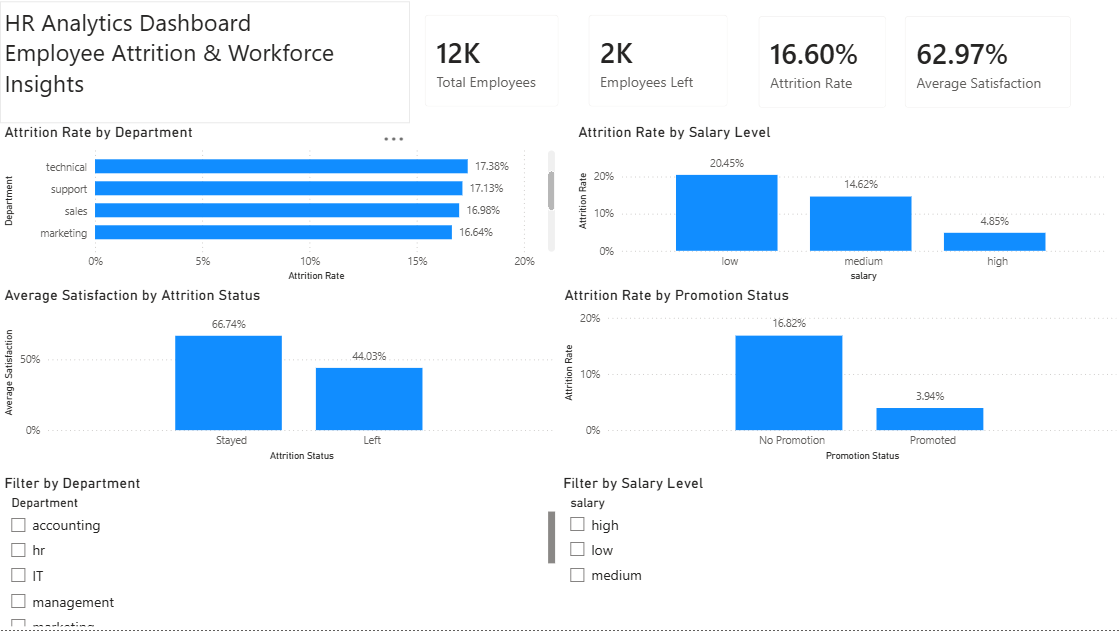

## Dashboard Insights

The Power BI dashboard provides a visual summary of employee attrition patterns across the organization.

Key findings include:

- The overall attrition rate is 16.60%, with approximately 2,000 employees leaving the company.
- Employees with low salary levels experience the highest attrition rate (20.45%), while high-salary employees show the lowest attrition rate (4.85%).
- Employees who received promotions have significantly lower attrition rates compared to those who were not promoted.
- Employees who left the company reported lower average satisfaction scores (44.03%) than employees who stayed (66.74%).
- Attrition rates vary across departments, indicating that some departments may require additional retention efforts.

The dashboard allows users to explore workforce trends through interactive filters and supports data-driven HR decision-making.

# 6. Recommendations & Conclusion

## Recommendations

1. Improve employee satisfaction through engagement and feedback initiatives.

2. Review compensation strategies for lower-salary employees, who experience higher attrition rates.

3. Monitor workload and working hours to reduce employee burnout.

4. Expand career development and promotion opportunities to improve retention.

5. Focus retention efforts on departments with higher attrition rates.

## Conclusion

This project identified several factors associated with employee attrition, including employee satisfaction, salary level, workload, promotion opportunities, and department-specific turnover patterns.

The findings demonstrate how HR analytics can support workforce planning and data-driven decision-making. By addressing these factors, organizations may improve employee retention and reduce turnover costs.